# Preprocesamiento de Datos para Inteligencia Artificial
## Facultad de Ingeniería - Universidad Nacional de Asunción
### Inteligencia Artificial 2026

**Diego Stalder** | **Christian Torres**

---

## 📌 Introducción

El preprocesamiento de datos es una etapa fundamental en cualquier proyecto de Machine Learning. 

> **"Entrada de basura → Salida de basura"**

Datos pobres conducen a malas predicciones y modelos deficientes. El preprocesamiento nos ayuda a:

* ✓ Limpiar datos inconsistentes
* ✓ Manejar valores faltantes
* ✓ Detectar y tratar valores atípicos
* ✓ Transformar variables para mejorar el rendimiento de los algoritmos
* ✓ Reducir dimensionalidad y sesgos

## 1. Configuración Inicial

In [1]:
# Importación de librerías necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración de visualización
%matplotlib inline
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

# Configuración de pandas
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

print("✅ Librerías importadas correctamente")

✅ Librerías importadas correctamente


## 2. Tipos de Datos en Machine Learning

| Tipo | Descripción | Ejemplo |
|------|-------------|---------|
| **Numérico (continuo)** | Valores con decimales | Ingreso: 650.34 |
| **Numérico (discreto)** | Valores enteros | # de hijos: 4 |
| **Booleano** | Verdadero/Falso | Sexo: Hombre (1/0) |
| **Categórico nominal** | Categorías sin orden | Colores: Rojo, Verde, Azul |
| **Categórico ordinal** | Categorías con orden | Satisfacción: Bajo, Medio, Alto |
| **Temporal** | Fechas y horas | Timestamps |

In [2]:
# Ejemplo de creación de DataFrame con diferentes tipos de datos
np.random.seed(42)

datos_ejemplo = {
    'edad': np.random.randint(18, 70, 20),
    'salario': np.random.normal(50000, 15000, 20).round(2),
    'genero': np.random.choice(['Masculino', 'Femenino'], 20),
    'nivel_educacion': np.random.choice(['Primaria', 'Secundaria', 'Universidad', 'Posgrado'], 20),
    'satisfaccion': np.random.choice(['Bajo', 'Medio', 'Alto'], 20),
    'fecha_registro': pd.date_range('2024-01-01', periods=20, freq='D'),
    'cliente_activo': np.random.choice([True, False], 20)
}

df_tipos = pd.DataFrame(datos_ejemplo)

print("📊 DataFrame con diferentes tipos de datos:")
print(df_tipos.head(10))
print("\n📋 Información de tipos:")
print(df_tipos.info())

📊 DataFrame con diferentes tipos de datos:
   edad  salario     genero nivel_educacion satisfaccion fecha_registro  \
0    56 42957.88  Masculino     Universidad        Medio     2024-01-01   
1    69 58138.40   Femenino     Universidad        Medio     2024-01-02   
2    46 43048.73   Femenino      Secundaria        Medio     2024-01-03   
3    32 43014.05  Masculino        Primaria        Medio     2024-01-04   
4    60 53629.43   Femenino        Posgrado         Alto     2024-01-05   
5    25 21300.80   Femenino      Secundaria         Alto     2024-01-06   
6    38 24126.23   Femenino        Posgrado        Medio     2024-01-07   
7    56 41565.69   Femenino        Posgrado         Alto     2024-01-08   
8    36 34807.53  Masculino      Secundaria         Bajo     2024-01-09   
9    40 54713.71   Femenino      Secundaria        Medio     2024-01-10   

   cliente_activo  
0            True  
1            True  
2            True  
3            True  
4            True  
5          

<Axes: title={'center': 'salario'}, xlabel='genero'>

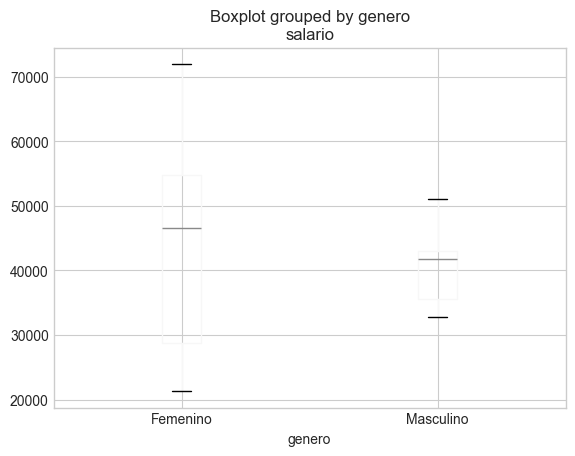

In [35]:
df_tipos.boxplot(column='salario', by='genero')

## 3. Manejo de Valores Nulos

### Tipos de datos faltantes:
* **MCAR** (Missing Completely At Random): Perdidos completamente al azar
* **MAR** (Missing At Random): Perdidos al azar (dependen de otras variables)
* **MNAR** (Missing Not At Random): No aleatorios (dependen del valor faltante)

### Estrategias de manejo:

In [3]:
# Creamos un dataset con valores nulos para ejemplificar
np.random.seed(123)

datos_con_nulos = {
    'ventas': np.random.normal(1000, 200, 50).round(2),
    'costos': np.random.normal(500, 100, 50).round(2),
    'categoria': np.random.choice(['A', 'B', 'C'], 50),
    'region': np.random.choice(['Norte', 'Sur', 'Este', 'Oeste'], 50)
}

df_nulos = pd.DataFrame(datos_con_nulos)

# Introducimos valores nulos intencionalmente
nulos_indices = np.random.choice(50, 10, replace=False)
df_nulos.loc[nulos_indices[:5], 'ventas'] = np.nan
df_nulos.loc[nulos_indices[5:8], 'costos'] = np.nan
df_nulos.loc[nulos_indices[8:10], 'categoria'] = np.nan

print("📉 Dataset con valores nulos:")
print(df_nulos.head(15))
print("\n🔍 Conteo de valores nulos por columna:")
print(df_nulos.isnull().sum())

📉 Dataset con valores nulos:
    ventas  costos categoria region
0   782.87  370.59         B  Norte
1  1199.47  396.12         B  Oeste
2  1056.60  674.37         A  Norte
3   698.74  420.19         C  Oeste
4   884.28  502.97         B  Oeste
5  1330.29  606.93       NaN  Oeste
6   514.66  589.07         C  Oeste
7   914.22  675.49         B   Este
8  1253.19  649.56         C    Sur
9   826.65     NaN         C    Sur
10  864.22  422.73         C  Oeste
11  981.06  579.49         B    Sur
12 1298.28  531.43         B    Sur
13  872.22  367.37         C    Sur
14  911.20  641.73         C   Este

🔍 Conteo de valores nulos por columna:
ventas       5
costos       3
categoria    2
region       0
dtype: int64


In [4]:
# 3.1 Eliminación de valores nulos

# Eliminar filas con al menos un valor nulo
df_drop_rows = df_nulos.dropna()
print("📌 Eliminación de filas con nulos:")
print(f"Filas originales: {len(df_nulos)}")
print(f"Filas después de dropna(): {len(df_drop_rows)}")

# Eliminar columnas con al menos un valor nulo
df_drop_cols = df_nulos.dropna(axis=1)
print("\n📌 Eliminación de columnas con nulos:")
print(f"Columnas originales: {df_nulos.shape[1]}")
print(f"Columnas después de dropna(axis=1): {df_drop_cols.shape[1]}")

# Eliminar filas donde una columna específica tenga nulos
df_drop_ventas = df_nulos.dropna(subset=['ventas'])
print(f"\n📌 Filas sin nulos en 'ventas': {len(df_drop_ventas)}")

📌 Eliminación de filas con nulos:
Filas originales: 50
Filas después de dropna(): 40

📌 Eliminación de columnas con nulos:
Columnas originales: 4
Columnas después de dropna(axis=1): 1

📌 Filas sin nulos en 'ventas': 45


In [5]:
# 3.2 Imputación de valores nulos con pandas

# Imputación con media (para variables numéricas)
df_mean = df_nulos.copy()
df_mean['ventas'] = df_mean['ventas'].fillna(df_mean['ventas'].mean())
df_mean['costos'] = df_mean['costos'].fillna(df_mean['costos'].mean())

# Imputación con mediana
df_median = df_nulos.copy()
df_median['ventas'] = df_median['ventas'].fillna(df_median['ventas'].median())
df_median['costos'] = df_median['costos'].fillna(df_median['costos'].median())

# Imputación con moda (para variables categóricas)
df_mode = df_nulos.copy()
df_mode['categoria'] = df_mode['categoria'].fillna(df_mode['categoria'].mode()[0])

print("📊 Comparación de métodos de imputación:")
print(f"Media de ventas: {df_nulos['ventas'].mean():.2f}")
print(f"Mediana de ventas: {df_nulos['ventas'].median():.2f}")
print(f"Moda de categoría: {df_nulos['categoria'].mode()[0]}")

# Imputación avanzada: diferente estrategia por tipo de dato
df_imputed_advanced = df_nulos.copy()
for col in df_imputed_advanced.columns:
    if df_imputed_advanced[col].dtype in ['float64', 'int64']:
        df_imputed_advanced[col] = df_imputed_advanced[col].fillna(df_imputed_advanced[col].median())
    else:
        df_imputed_advanced[col] = df_imputed_advanced[col].fillna(df_imputed_advanced[col].mode()[0])

print("\n✅ Dataset después de imputación avanzada (mediana para numéricas, moda para categóricas):")
print(df_imputed_advanced.isnull().sum())

📊 Comparación de métodos de imputación:
Media de ventas: 1022.39
Mediana de ventas: 997.63
Moda de categoría: B

✅ Dataset después de imputación avanzada (mediana para numéricas, moda para categóricas):
ventas       0
costos       0
categoria    0
region       0
dtype: int64


In [ ]:
# 3.3 Imputación con Scikit-learn
from sklearn.impute import SimpleImputer

# Preparar datos (solo numéricos para este ejemplo)
df_num = df_nulos[['ventas', 'costos']].copy()

# Imputación con media usando SimpleImputer
imputer_mean = SimpleImputer(strategy='mean')
df_imputed_sklearn = pd.DataFrame( imputer_mean.fit_transform(df_num),columns=df_num.columns)

# Imputación con mediana
imputer_median = SimpleImputer(strategy='median')
df_imputed_median_sk = pd.DataFrame(
    imputer_median.fit_transform(df_num),
    columns=df_num.columns
)

# Imputación con constante
imputer_constant = SimpleImputer(strategy='constant', fill_value=0)
df_imputed_const_sk = pd.DataFrame(
    imputer_constant.fit_transform(df_num),
    columns=df_num.columns
)

print("📊 Resultados de imputación con Scikit-learn:")
print("\nMedia imputada:")
print(df_imputed_sklearn.head())
print("\nMediana imputada:")
print(df_imputed_median_sk.head())

📊 Resultados de imputación con Scikit-learn:

Media imputada:
   ventas  costos
0  782.87  370.59
1 1199.47  396.12
2 1056.60  674.37
3  698.74  420.19
4  884.28  502.97

Mediana imputada:
   ventas  costos
0  782.87  370.59
1 1199.47  396.12
2 1056.60  674.37
3  698.74  420.19
4  884.28  502.97


In [37]:
df_num.head()

,ventas,costos
0,782.87,370.59
1,1199.47,396.12
2,1056.60,674.37
3,698.74,420.19
4,884.28,502.97


In [36]:
# 3.4 Imputación avanzada: KNNImputer e IterativeImputer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import KNNImputer, IterativeImputer

# KNN Imputer (usa vecinos más cercanos para imputar)
knn_imputer = KNNImputer(n_neighbors=3)
knn_imputer.fit_transform(df_num)

array([[ 782.87      ,  370.59      ],
       [1199.47      ,  396.12      ],
       [1056.6       ,  674.37      ],
       [ 698.74      ,  420.19      ],
       [ 884.28      ,  502.97      ],
       [1330.29      ,  606.93      ],
       [ 514.66      ,  589.07      ],
       [ 914.22      ,  675.49      ],
       [1253.19      ,  649.56      ],
       [ 826.65      ,  539.49333333],
       [ 864.22      ,  422.73      ],
       [ 981.06      ,  579.49      ],
       [1298.28      ,  531.43      ],
       [ 872.22      ,  367.37      ],
       [ 911.2       ,  641.73      ],
       [ 913.13      ,  580.72      ],
       [1441.19      ,  504.55      ],
       [1437.36      ,  476.69      ],
       [1200.81      ,  380.17      ],
       [1077.24      ,  519.95      ],
       [1147.47      ,  546.84      ],
       [1298.15      ,  416.88      ],
       [1094.66      ,  616.22      ],
       [1235.17      ,  390.28      ],
       [ 749.22      ,  287.69      ],
       [ 872.45      ,  6

In [38]:
# 3.4 Imputación avanzada: KNNImputer e IterativeImputer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import KNNImputer, IterativeImputer

# KNN Imputer (usa vecinos más cercanos para imputar)
knn_imputer = KNNImputer(n_neighbors=3)
df_knn = pd.DataFrame(
    knn_imputer.fit_transform(df_num),
    columns=df_num.columns
)

# Iterative Imputer (modela cada variable en función de las demás)
iter_imputer = IterativeImputer(max_iter=10, random_state=42)
df_iter = pd.DataFrame(
    iter_imputer.fit_transform(df_num),
    columns=df_num.columns
)

print("📊 Comparación de métodos avanzados de imputación:")
comparacion = pd.DataFrame({
    'Original': df_num['ventas'],
    'KNN': df_knn['ventas'],
    'Iterative': df_iter['ventas']
})
comparacion.to_csv("comparacion_imputacion.csv", index=False)

📊 Comparación de métodos avanzados de imputación:


<Axes: >

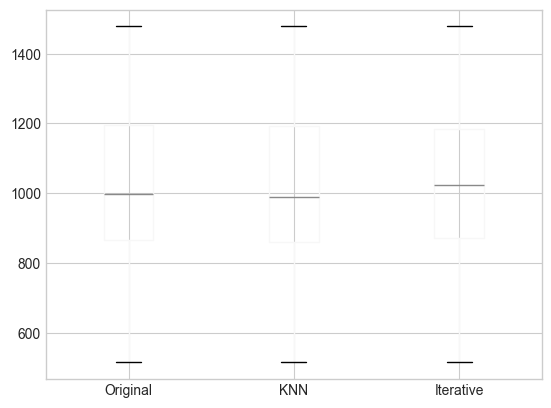

In [40]:
comparacion.boxplot(column=['Original', 'KNN', 'Iterative'])

Text(0.5, 1.0, 'Comparación de métodos de imputación para "ventas"')

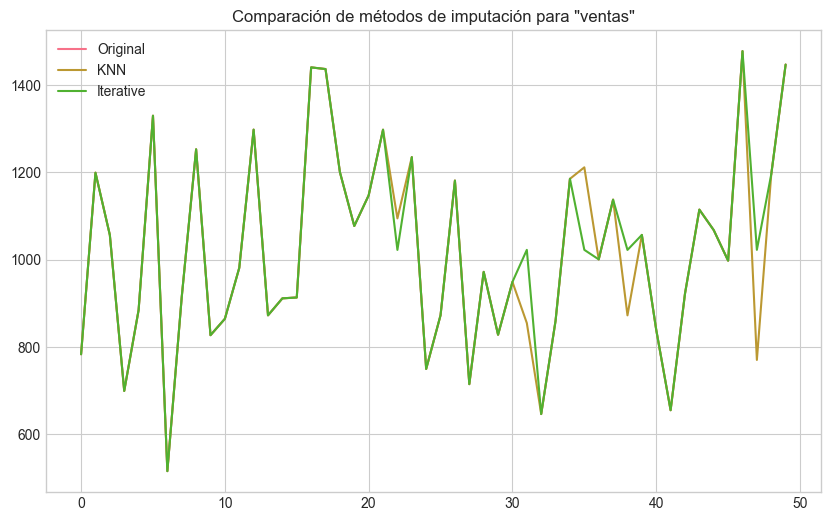

In [39]:
comparacion.plot(kind='line', figsize=(10, 6))
plt.title('Comparación de métodos de imputación para "ventas"')

## 4. Detección y Manejo de Valores Atípicos (Outliers)

Los valores atípicos pueden deberse a:
* Errores experimentales
* Variabilidad natural
* Distribuciones sesgadas
* Poblaciones mixtas

### Métodos de detección:

In [8]:
# Creamos un dataset con outliers
np.random.seed(42)
datos_outliers = {
    'normal': np.random.normal(100, 15, 200),
    'sesgada': np.random.exponential(50, 200),
    'con_outliers': np.random.normal(100, 15, 200)
}

df_outliers = pd.DataFrame(datos_outliers)

# Introducimos outliers intencionalmente
df_outliers.loc[0:4, 'con_outliers'] = [200, 250, 20, 15, 300]
df_outliers.loc[150:155, 'con_outliers'] = [10, 8, 350, 12, 9, 280]

print("📊 Dataset con outliers:")
print(df_outliers.describe())

📊 Dataset con outliers:
       normal  sesgada  con_outliers
count  200.00   200.00        200.00
mean    99.39    48.34        101.11
std     13.97    45.27         36.04
min     60.70     0.54          8.00
25%     89.42    14.36         87.79
50%     99.94    36.06         99.11
75%    107.51    69.84        109.60
max    140.80   232.85        350.00


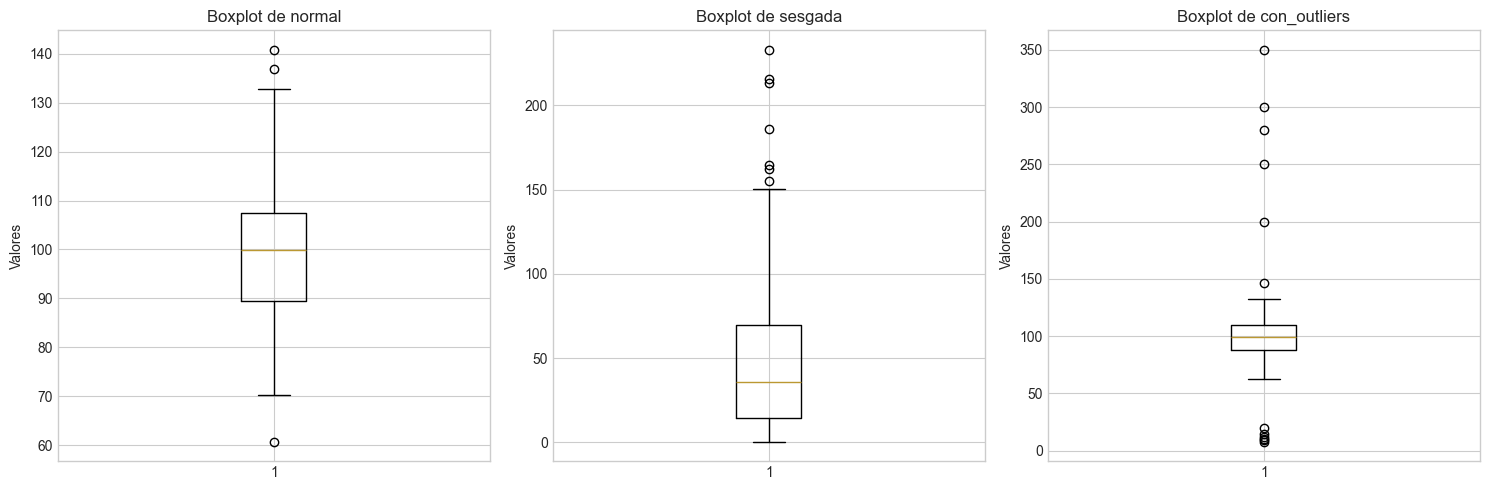

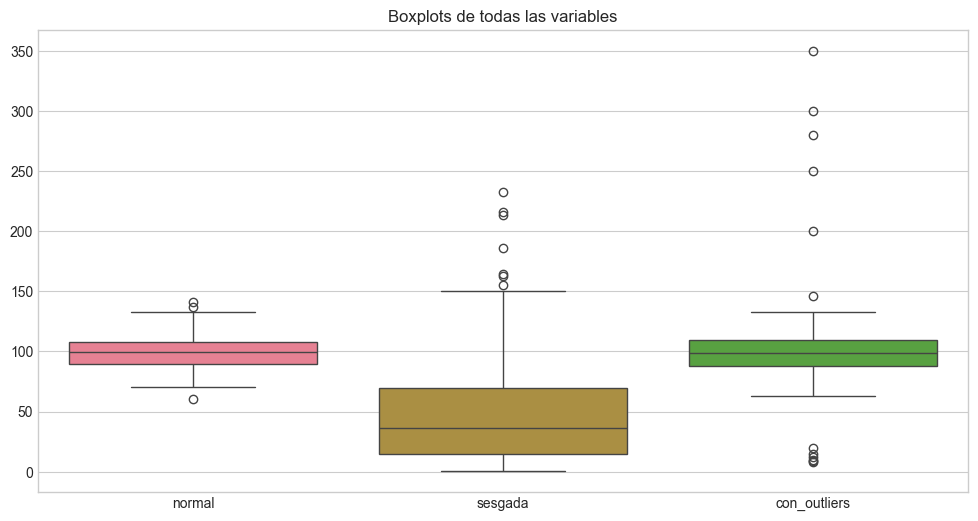

In [9]:
# 4.1 Visualización de outliers con boxplots

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, col in enumerate(df_outliers.columns):
    axes[i].boxplot(df_outliers[col])
    axes[i].set_title(f'Boxplot de {col}')
    axes[i].set_ylabel('Valores')

plt.tight_layout()
plt.show()

# También podemos usar seaborn
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_outliers)
plt.title('Boxplots de todas las variables')
plt.show()

In [10]:
# 4.2 Detección de outliers con el método IQR (Rango Intercuartílico)

def detectar_outliers_iqr(df, columna, threshold=1.5):
    """
    Detecta outliers usando el método del rango intercuartílico
    """
    Q1 = df[columna].quantile(0.25)
    Q3 = df[columna].quantile(0.75)
    IQR = Q3 - Q1
    
    limite_inferior = Q1 - threshold * IQR
    limite_superior = Q3 + threshold * IQR
    
    outliers = df[(df[columna] < limite_inferior) | (df[columna] > limite_superior)]
    
    return outliers, limite_inferior, limite_superior

# Aplicamos a cada columna
for col in df_outliers.columns:
    outliers, li, ls = detectar_outliers_iqr(df_outliers, col)
    print(f"\n📌 Columna '{col}':")
    print(f"   Límite inferior: {li:.2f}, Límite superior: {ls:.2f}")
    print(f"   Outliers detectados: {len(outliers)} ({len(outliers)/len(df_outliers)*100:.1f}%)")
    if len(outliers) > 0:
        print(f"   Valores outliers: {outliers[col].tolist()}")


📌 Columna 'normal':
   Límite inferior: 62.29, Límite superior: 134.65
   Outliers detectados: 3 (1.5%)
   Valores outliers: [60.703823438653835, 136.9486316872793, 140.8025374988443]

📌 Columna 'sesgada':
   Límite inferior: -68.87, Límite superior: 153.07
   Outliers detectados: 7 (3.5%)
   Valores outliers: [186.17785043499964, 164.3689961634301, 154.90517492781532, 162.4545930753377, 232.85024450701152, 215.77292810290461, 213.4386969800992]

📌 Columna 'con_outliers':
   Límite inferior: 55.07, Límite superior: 142.32
   Outliers detectados: 12 (6.0%)
   Valores outliers: [200.0, 250.0, 20.0, 15.0, 300.0, 146.18321212682855, 10.0, 8.0, 350.0, 12.0, 9.0, 280.0]


In [11]:
# 4.3 Detección de outliers con Z-Score
from scipy import stats

def detectar_outliers_zscore(df, columna, threshold=3):
    """
    Detecta outliers usando Z-Score (valores con |z| > threshold)
    """
    z_scores = np.abs(stats.zscore(df[columna], nan_policy='omit'))
    outliers = df[z_scores > threshold]
    return outliers, z_scores

print("📊 Detección de outliers con Z-Score (threshold=3):")
for col in df_outliers.columns:
    outliers, z_scores = detectar_outliers_zscore(df_outliers, col)
    print(f"\n📌 Columna '{col}': {len(outliers)} outliers detectados")
    if len(outliers) > 0:
        print(f"   Índices: {outliers.index.tolist()}")

📊 Detección de outliers con Z-Score (threshold=3):

📌 Columna 'normal': 0 outliers detectados

📌 Columna 'sesgada': 4 outliers detectados
   Índices: [41, 126, 177, 182]

📌 Columna 'con_outliers': 4 outliers detectados
   Índices: [1, 4, 152, 155]


📊 Comparación de métodos de manejo de outliers:

Original - con_outliers:
count   200.00
mean    101.11
std      36.04
min       8.00
25%      87.79
50%      99.11
75%     109.60
max     350.00
Name: con_outliers, dtype: float64

Eliminación - con_outliers:
count   188.00
mean     99.05
std      15.12
min      62.93
25%      88.33
50%      99.11
75%     108.80
max     132.85
Name: con_outliers, dtype: float64

Winsorizing - con_outliers:
count   200.00
mean     99.03
std      18.16
min      55.07
25%      87.79
50%      99.11
75%     109.60
max     142.32
Name: con_outliers, dtype: float64

Transformación Log - con_outliers:
count   200.00
mean      4.46
std       0.56
min       0.69
25%       4.40
50%       4.53
75%       4.64
max       5.84
Name: con_outliers, dtype: float64


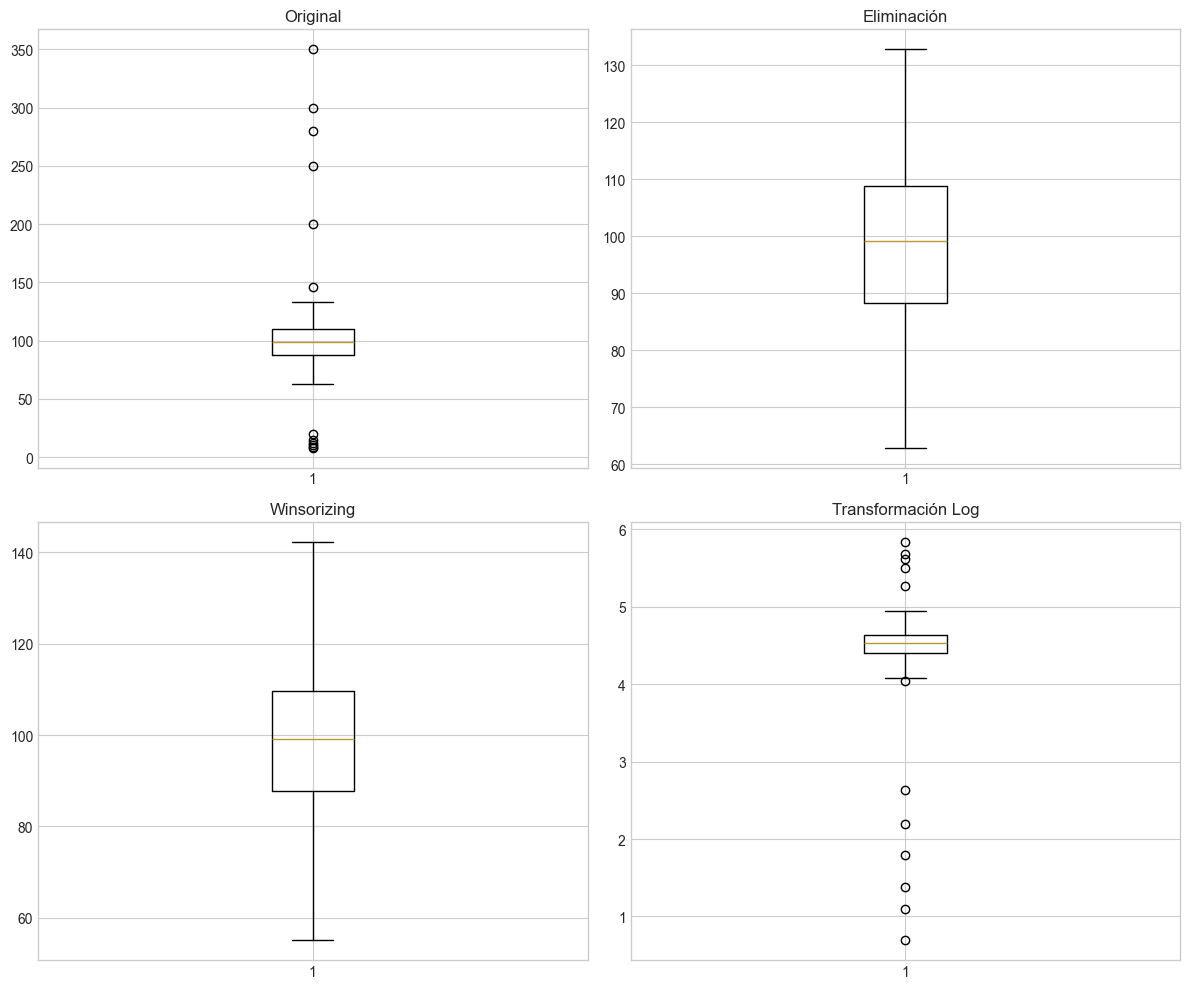

In [12]:
# 4.4 Manejo de outliers

df_outliers_clean = df_outliers.copy()
columna_problema = 'con_outliers'

# Método 1: Eliminación de outliers
outliers, li, ls = detectar_outliers_iqr(df_outliers_clean, columna_problema)
df_sin_outliers = df_outliers_clean[
    (df_outliers_clean[columna_problema] >= li) & 
    (df_outliers_clean[columna_problema] <= ls)
]

# Método 2: Winsorizing (reemplazar outliers por los límites)
df_winsorized = df_outliers_clean.copy()
df_winsorized[columna_problema] = df_winsorized[columna_problema].clip(li, ls)

# Método 3: Transformación logarítmica (para mitigar el efecto)
df_log = df_outliers_clean.copy()
df_log[columna_problema] = np.log1p(df_log[columna_problema] - df_log[columna_problema].min() + 1)

print("📊 Comparación de métodos de manejo de outliers:")
print(f"\nOriginal - {columna_problema}:")
print(df_outliers_clean[columna_problema].describe())

print(f"\nEliminación - {columna_problema}:")
print(df_sin_outliers[columna_problema].describe())

print(f"\nWinsorizing - {columna_problema}:")
print(df_winsorized[columna_problema].describe())

print(f"\nTransformación Log - {columna_problema}:")
print(df_log[columna_problema].describe())

# Visualización comparativa
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

axes[0, 0].boxplot(df_outliers_clean[columna_problema])
axes[0, 0].set_title('Original')

axes[0, 1].boxplot(df_sin_outliers[columna_problema])
axes[0, 1].set_title('Eliminación')

axes[1, 0].boxplot(df_winsorized[columna_problema])
axes[1, 0].set_title('Winsorizing')

axes[1, 1].boxplot(df_log[columna_problema])
axes[1, 1].set_title('Transformación Log')

plt.tight_layout()
plt.show()

## 5. Escalado y Normalización de Datos

### ¿Por qué escalar?
* ✓ Facilita la comparación de valores
* ✓ Necesario para algoritmos sensibles a la escala (SVM, KNN, redes neuronales)
* ✓ Mejora la convergencia en gradient descent

### Métodos principales:

In [13]:
# Creamos datos con diferentes escalas
np.random.seed(42)
datos_escala = {
    'edad': np.random.randint(18, 80, 100),
    'salario': np.random.normal(50000, 20000, 100).round(2),
    'experiencia': np.random.randint(0, 40, 100),
    'hijos': np.random.randint(0, 5, 100)
}

df_escala = pd.DataFrame(datos_escala)

print("📊 Datos originales (diferentes escalas):")
print(df_escala.describe())

📊 Datos originales (diferentes escalas):
        edad   salario  experiencia  hijos
count 100.00    100.00       100.00 100.00
mean   50.27  50419.67        21.00   1.97
std    19.18  19731.18        11.61   1.47
min    19.00     24.82         0.00   0.00
25%    34.75  35870.46        11.00   1.00
50%    51.50  49507.43        21.50   2.00
75%    68.00  64182.24        32.00   3.00
max    79.00 103120.20        39.00   4.00


In [14]:
# 5.1 Min-Max Scaling (Normalización a [0,1])
from sklearn.preprocessing import MinMaxScaler

# Implementación con pandas
df_minmax_pandas = (df_escala - df_escala.min()) / (df_escala.max() - df_escala.min())

# Implementación con scikit-learn
scaler_minmax = MinMaxScaler()
df_minmax_sk = pd.DataFrame(
    scaler_minmax.fit_transform(df_escala),
    columns=df_escala.columns
)

# Min-Max a [-1, 1]
def minmax_to_range(df, feature_range=(-1, 1)):
    min_val, max_val = feature_range
    df_min = df.min()
    df_max = df.max()
    return (df - df_min) / (df_max - df_min) * (max_val - min_val) + min_val

df_minmax_neg1_1 = minmax_to_range(df_escala, (-1, 1))

print("📊 Min-Max Scaling [0,1]:")
print(df_minmax_sk.describe())

print("📊 Min-Max Scaling [-1,1]:")
print(df_minmax_neg1_1.describe())

📊 Min-Max Scaling [0,1]:
        edad  salario  experiencia  hijos
count 100.00   100.00       100.00 100.00
mean    0.52     0.49         0.54   0.49
std     0.32     0.19         0.30   0.37
min     0.00     0.00         0.00   0.00
25%     0.26     0.35         0.28   0.25
50%     0.54     0.48         0.55   0.50
75%     0.82     0.62         0.82   0.75
max     1.00     1.00         1.00   1.00
📊 Min-Max Scaling [-1,1]:
        edad  salario  experiencia  hijos
count 100.00   100.00       100.00 100.00
mean    0.04    -0.02         0.08  -0.01
std     0.64     0.38         0.60   0.73
min    -1.00    -1.00        -1.00  -1.00
25%    -0.47    -0.30        -0.44  -0.50
50%     0.08    -0.04         0.10   0.00
75%     0.63     0.24         0.64   0.50
max     1.00     1.00         1.00   1.00


Text(0.5, 1.0, 'Datos originales (diferentes escalas)')

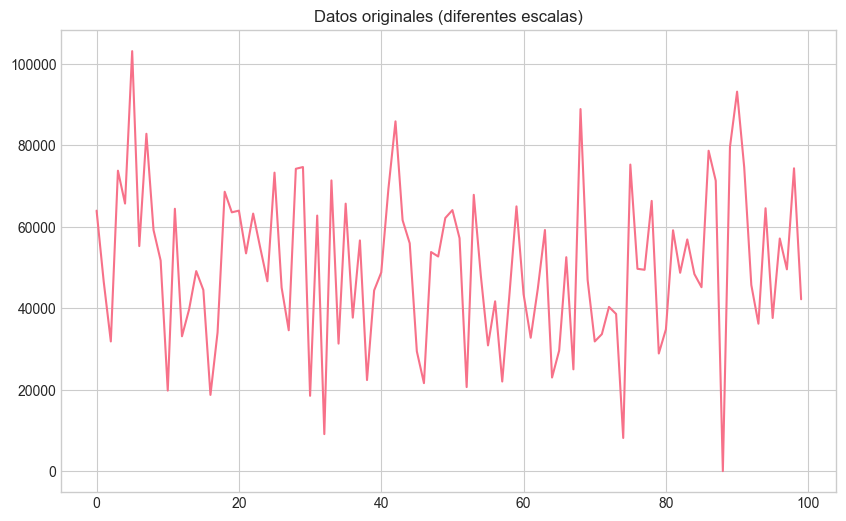

In [45]:
df_escala['salario'].plot(kind="line", figsize=(10, 6))
plt.title('Datos originales (diferentes escalas)')


Text(0.5, 1.0, 'Min-Max Scaling a [-1, 1]')

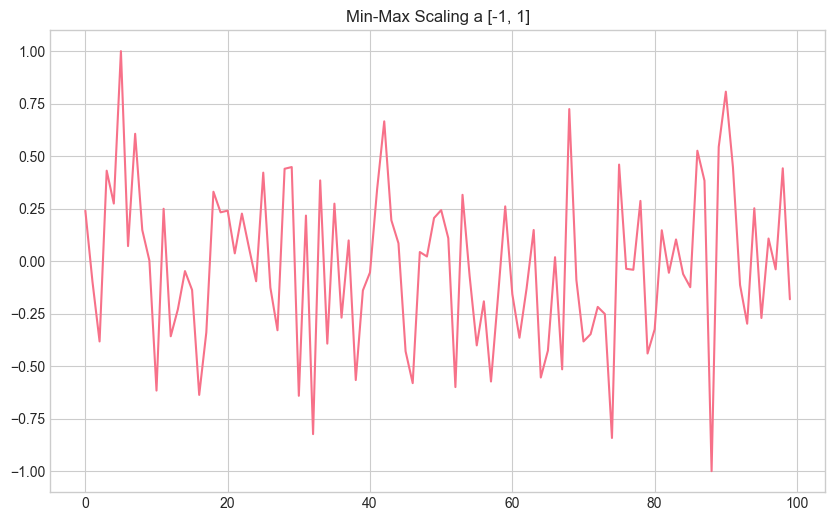

In [46]:
df_minmax_neg1_1['salario'].plot(kind="line", figsize=(10, 6))
plt.title('Min-Max Scaling a [-1, 1]')

In [15]:
# 5.2 Standardization (Z-Score Normalization)
from sklearn.preprocessing import StandardScaler

# Implementación con pandas
df_standard_pandas = (df_escala - df_escala.mean()) / df_escala.std()

# Implementación con scikit-learn
scaler_standard = StandardScaler()
df_standard_sk = pd.DataFrame(
    scaler_standard.fit_transform(df_escala),
    columns=df_escala.columns
)

print("📊 Standardization (Z-Score):")
print(df_standard_sk.describe())
print("✅ Media ≈ 0, Desviación estándar ≈ 1")

📊 Standardization (Z-Score):
        edad  salario  experiencia  hijos
count 100.00   100.00       100.00 100.00
mean   -0.00    -0.00        -0.00   0.00
std     1.01     1.01         1.01   1.01
min    -1.64    -2.57        -1.82  -1.35
25%    -0.81    -0.74        -0.87  -0.66
50%     0.06    -0.05         0.04   0.02
75%     0.93     0.70         0.95   0.71
max     1.51     2.68         1.56   1.39
✅ Media ≈ 0, Desviación estándar ≈ 1


In [16]:
# 5.3 Robust Scaling (usando mediana y IQR)
from sklearn.preprocessing import RobustScaler

scaler_robust = RobustScaler()
df_robust_sk = pd.DataFrame(
    scaler_robust.fit_transform(df_escala),
    columns=df_escala.columns
)

# Implementación manual
def robust_scale_manual(df):
    median = df.median()
    q1 = df.quantile(0.25)
    q3 = df.quantile(0.75)
    iqr = q3 - q1
    return (df - median) / iqr

df_robust_manual = robust_scale_manual(df_escala)

print("📊 Robust Scaling (basado en mediana e IQR):")
print(df_robust_sk.describe())
print("✅ Robusto ante outliers")

📊 Robust Scaling (basado en mediana e IQR):
        edad  salario  experiencia  hijos
count 100.00   100.00       100.00 100.00
mean   -0.04     0.03        -0.02  -0.01
std     0.58     0.70         0.55   0.73
min    -0.98    -1.75        -1.02  -1.00
25%    -0.50    -0.48        -0.50  -0.50
50%     0.00    -0.00         0.00   0.00
75%     0.50     0.52         0.50   0.50
max     0.83     1.89         0.83   1.00
✅ Robusto ante outliers


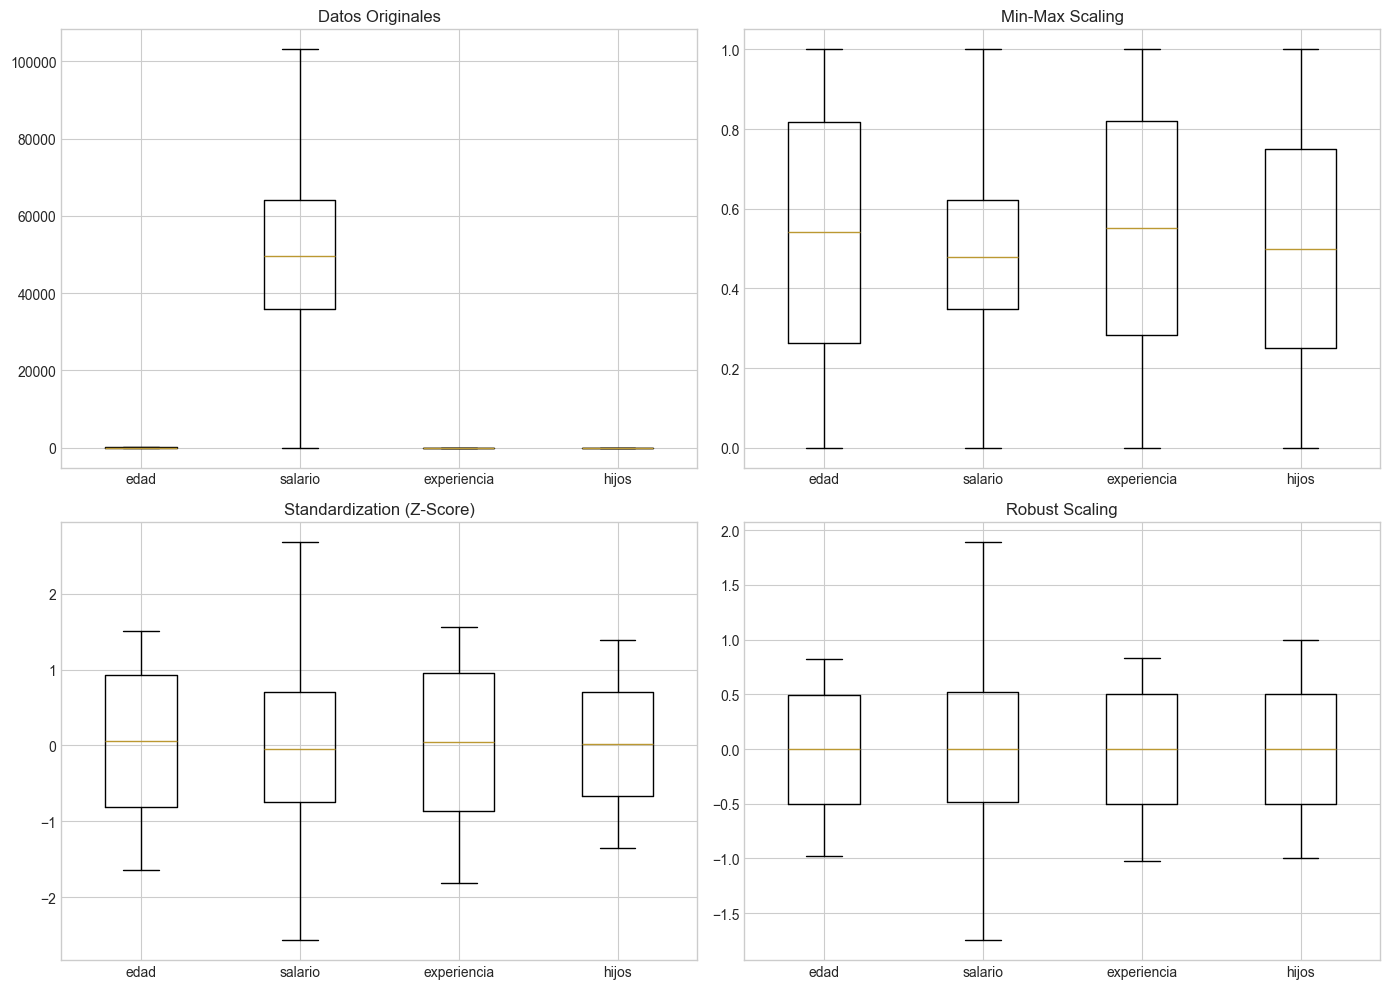

In [17]:
# 5.4 Comparación visual de métodos de escalado

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Datos originales
axes[0, 0].boxplot(df_escala.values)
axes[0, 0].set_title('Datos Originales')
axes[0, 0].set_xticklabels(df_escala.columns)

# Min-Max
axes[0, 1].boxplot(df_minmax_sk.values)
axes[0, 1].set_title('Min-Max Scaling')
axes[0, 1].set_xticklabels(df_escala.columns)

# Standardization
axes[1, 0].boxplot(df_standard_sk.values)
axes[1, 0].set_title('Standardization (Z-Score)')
axes[1, 0].set_xticklabels(df_escala.columns)

# Robust Scaling
axes[1, 1].boxplot(df_robust_sk.values)
axes[1, 1].set_title('Robust Scaling')
axes[1, 1].set_xticklabels(df_escala.columns)

plt.tight_layout()
plt.show()

In [18]:
# 5.5 Guía para elegir el método de normalización

def recomendar_escalado(df, columna):
    """
    Recomienda un método de escalado basado en las características de los datos
    """
    datos = df[columna].dropna()
    
    # Estadísticas descriptivas
    media = datos.mean()
    mediana = datos.median()
    std = datos.std()
    rango = datos.max() - datos.min()
    asimetria = datos.skew()
    
    print(f"\n📊 Análisis para '{columna}':")
    print(f"   Media: {media:.2f}, Mediana: {mediana:.2f}")
    print(f"   Desviación estándar: {std:.2f}")
    print(f"   Rango: {rango:.2f}")
    print(f"   Asimetría: {asimetria:.2f}")
    
    # Recomendación
    if rango > 1000000 or abs(asimetria) > 2:
        print("   ✅ Recomendación: Transformación logarítmica + StandardScaler")
    elif abs(asimetria) > 1:
        print("   ✅ Recomendación: RobustScaler (resistente a outliers)")
    elif abs(media - mediana) / std < 0.1:
        print("   ✅ Recomendación: StandardScaler (datos normales)")
    else:
        print("   ✅ Recomendación: MinMaxScaler (rango acotado)")

# Aplicamos a cada columna
for col in df_escala.columns:
    recomendar_escalado(df_escala, col)


📊 Análisis para 'edad':
   Media: 50.27, Mediana: 51.50
   Desviación estándar: 19.18
   Rango: 60.00
   Asimetría: -0.07
   ✅ Recomendación: StandardScaler (datos normales)

📊 Análisis para 'salario':
   Media: 50419.67, Mediana: 49507.43
   Desviación estándar: 19731.18
   Rango: 103095.38
   Asimetría: -0.02
   ✅ Recomendación: StandardScaler (datos normales)

📊 Análisis para 'experiencia':
   Media: 21.00, Mediana: 21.50
   Desviación estándar: 11.61
   Rango: 39.00
   Asimetría: -0.26
   ✅ Recomendación: StandardScaler (datos normales)

📊 Análisis para 'hijos':
   Media: 1.97, Mediana: 2.00
   Desviación estándar: 1.47
   Rango: 4.00
   Asimetría: 0.09
   ✅ Recomendación: StandardScaler (datos normales)


## 6. Codificación de Variables Categóricas

Las variables categóricas deben convertirse a formato numérico para la mayoría de algoritmos de ML.

In [19]:
# Creamos dataset con variables categóricas
np.random.seed(42)

datos_categoricos = {
    'color': np.random.choice(['Rojo', 'Verde', 'Azul', 'Amarillo'], 50),
    'tamaño': np.random.choice(['Pequeño', 'Mediano', 'Grande'], 50),
    'ciudad': np.random.choice(['Asunción', 'Ciudad del Este', 'Encarnación', 'Luque'], 50),
    'satisfaccion': np.random.choice(['Bajo', 'Medio', 'Alto'], 50),
    'dia_semana': np.random.choice(['Lunes', 'Martes', 'Miércoles', 'Jueves', 'Viernes'], 50)
}

df_cat = pd.DataFrame(datos_categoricos)

print("📊 Dataset con variables categóricas:")
print(df_cat.head(10))

📊 Dataset con variables categóricas:
      color   tamaño           ciudad satisfaccion dia_semana
0      Azul   Grande            Luque         Bajo     Jueves
1  Amarillo  Mediano         Asunción         Alto     Jueves
2      Rojo   Grande  Ciudad del Este        Medio     Jueves
3      Azul   Grande      Encarnación         Alto     Jueves
4      Azul  Pequeño         Asunción         Alto     Jueves
5  Amarillo   Grande            Luque         Bajo  Miércoles
6      Rojo  Pequeño  Ciudad del Este         Alto     Martes
7      Rojo   Grande         Asunción         Bajo     Jueves
8      Azul   Grande            Luque         Alto      Lunes
9     Verde  Pequeño            Luque        Medio      Lunes


In [20]:
# 6.1 One-Hot Encoding con pandas (get_dummies)

# One-Hot Encoding simple
df_onehot_pd = pd.get_dummies(df_cat)
print("📊 One-Hot Encoding con pandas:")
print(f"Dimensiones originales: {df_cat.shape}")
print(f"Dimensiones después de One-Hot: {df_onehot_pd.shape}")
print(df_onehot_pd.head())

# One-Hot Encoding con drop_first para evitar multicolinealidad
df_onehot_drop = pd.get_dummies(df_cat, drop_first=True)
print(f"📊 One-Hot Encoding con drop_first: {df_onehot_drop.shape}")

📊 One-Hot Encoding con pandas:
Dimensiones originales: (50, 5)
Dimensiones después de One-Hot: (50, 19)
   color_Amarillo  color_Azul  color_Rojo  color_Verde  tamaño_Grande  \
0           False        True       False        False           True   
1            True       False       False        False          False   
2           False       False        True        False           True   
3           False        True       False        False           True   
4           False        True       False        False          False   

   tamaño_Mediano  tamaño_Pequeño  ciudad_Asunción  ciudad_Ciudad del Este  \
0           False           False            False                   False   
1            True           False             True                   False   
2           False           False            False                    True   
3           False           False            False                   False   
4           False            True             True                 

In [21]:
# 6.2 One-Hot Encoding con Scikit-learn
from sklearn.preprocessing import OneHotEncoder

# OneHotEncoder devuelve una matriz sparse
encoder = OneHotEncoder(sparse_output=False, drop='first')
encoded_array = encoder.fit_transform(df_cat)

# Obtener nombres de las características
feature_names = encoder.get_feature_names_out(df_cat.columns)
df_onehot_sk = pd.DataFrame(encoded_array, columns=feature_names)

print("📊 One-Hot Encoding con Scikit-learn:")
print(df_onehot_sk.head())

📊 One-Hot Encoding con Scikit-learn:
   color_Azul  color_Rojo  color_Verde  tamaño_Mediano  tamaño_Pequeño  \
0        1.00        0.00         0.00            0.00            0.00   
1        0.00        0.00         0.00            1.00            0.00   
2        0.00        1.00         0.00            0.00            0.00   
3        1.00        0.00         0.00            0.00            0.00   
4        1.00        0.00         0.00            0.00            1.00   

   ciudad_Ciudad del Este  ciudad_Encarnación  ciudad_Luque  \
0                    0.00                0.00          1.00   
1                    0.00                0.00          0.00   
2                    1.00                0.00          0.00   
3                    0.00                1.00          0.00   
4                    0.00                0.00          0.00   

   satisfaccion_Bajo  satisfaccion_Medio  dia_semana_Lunes  dia_semana_Martes  \
0               1.00                0.00              0.00

In [22]:
# 6.3 Label Encoding (para variables ordinales)
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder

# LabelEncoder para una sola columna
label_encoder = LabelEncoder()
df_cat['satisfaccion_encoded'] = label_encoder.fit_transform(df_cat['satisfaccion'])

print("📊 Label Encoding para satisfacción:")
print(df_cat[['satisfaccion', 'satisfaccion_encoded']].drop_duplicates())

# OrdinalEncoder con orden personalizado
orden_satisfaccion = [['Bajo', 'Medio', 'Alto']]
ordinal_encoder = OrdinalEncoder(categories=orden_satisfaccion)
df_cat['satisfaccion_ordinal'] = ordinal_encoder.fit_transform(df_cat[['satisfaccion']])

print("\n📊 Ordinal Encoding con orden personalizado:")
print(df_cat[['satisfaccion', 'satisfaccion_ordinal']].drop_duplicates().sort_values('satisfaccion_ordinal'))

📊 Label Encoding para satisfacción:
  satisfaccion  satisfaccion_encoded
0         Bajo                     1
1         Alto                     0
2        Medio                     2

📊 Ordinal Encoding con orden personalizado:
  satisfaccion  satisfaccion_ordinal
0         Bajo                  0.00
2        Medio                  1.00
1         Alto                  2.00


📊 Codificación cíclica para días de la semana:
   dia_semana  dia_semana_sin  dia_semana_cos
0      Jueves           -0.59           -0.81
5   Miércoles            0.59           -0.81
6      Martes            0.95            0.31
8       Lunes            0.00            1.00
15    Viernes           -0.95            0.31


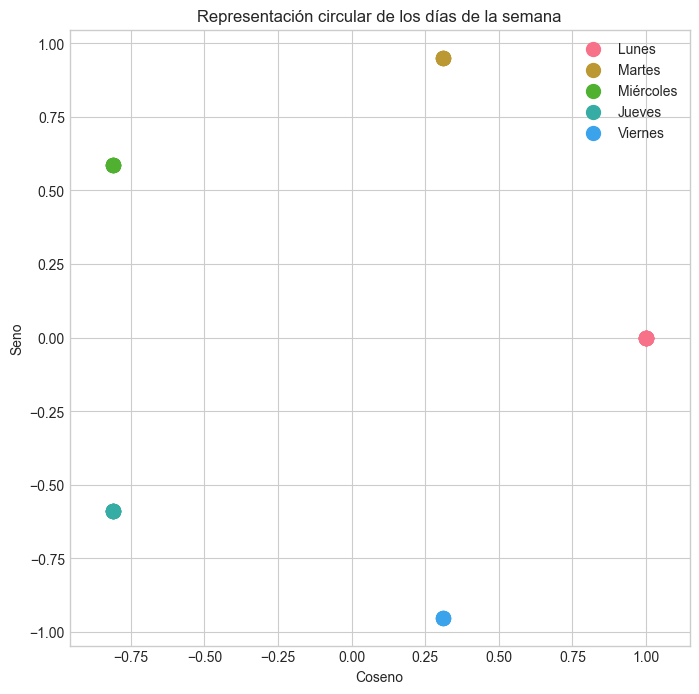

In [ ]:
# 6.4 Codificación para variables cíclicas (ejemplo: días de la semana)

def codificacion_ciclica(df, columna, orden_categorias):
    """
    Codifica variables cíclicas usando seno y coseno
    """
    df_ciclica = df.copy()
    
    # Mapear categorías a números
    categoria_a_numero = {cat: i for i, cat in enumerate(orden_categorias)}
    numeros = df_ciclica[columna].map(categoria_a_numero)
    
    # Aplicar seno y coseno
    angulos = numeros * (2 * np.pi / len(orden_categorias))
    df_ciclica[f'{columna}_sin'] = np.sin(angulos)
    df_ciclica[f'{columna}_cos'] = np.cos(angulos)
    
    return df_ciclica

orden_dias = ['Lunes', 'Martes', 'Miércoles', 'Jueves', 'Viernes']
df_ciclica = codificacion_ciclica(df_cat, 'dia_semana', orden_dias)

print("📊 Codificación cíclica para días de la semana:")
print(df_ciclica[['dia_semana', 'dia_semana_sin', 'dia_semana_cos']].drop_duplicates())

# Visualización
plt.figure(figsize=(8, 8))
for dia in orden_dias:
    subset = df_ciclica[df_ciclica['dia_semana'] == dia]
    plt.scatter(subset['dia_semana_cos'], subset['dia_semana_sin'], label=dia, s=100)

plt.xlabel('Coseno')
plt.ylabel('Seno')
plt.title('Representación circular de los días de la semana')
plt.legend()
plt.grid(True)
plt.axis('equal')
plt.show()

In [24]:
# 6.5 Frequency Encoding (para categorías con muchas cardinalidades)

def frequency_encoding(df, columna):
    """
    Codifica usando la frecuencia de cada categoría
    """
    freq = df[columna].value_counts() / len(df)
    df_encoded = df.copy()
    df_encoded[f'{columna}_freq'] = df_encoded[columna].map(freq)
    return df_encoded, freq

df_freq, frecuencias = frequency_encoding(df_cat, 'ciudad')

print("📊 Frequency Encoding para 'ciudad':")
print("Frecuencias:", frecuencias)
print("Datos codificados:")
print(df_freq[['ciudad', 'ciudad_freq']].drop_duplicates())

📊 Frequency Encoding para 'ciudad':
Frecuencias: ciudad
Asunción          0.34
Luque             0.28
Encarnación       0.26
Ciudad del Este   0.12
Name: count, dtype: float64
Datos codificados:
            ciudad  ciudad_freq
0            Luque         0.28
1         Asunción         0.34
2  Ciudad del Este         0.12
3      Encarnación         0.26


## 7. Discretización de Datos

Convertir variables continuas en categóricas (bins).

📊 Datos para discretización:
        edad   ingreso  puntuacion
count 200.00    200.00      200.00
mean   39.39  48336.03       50.24
std    13.97  45270.57       29.45
min     0.70    544.84        1.22
25%    29.42  14358.49       24.61
50%    39.94  36059.61       50.09
75%    47.51  69842.66       75.00
max    80.80 232850.24       99.97


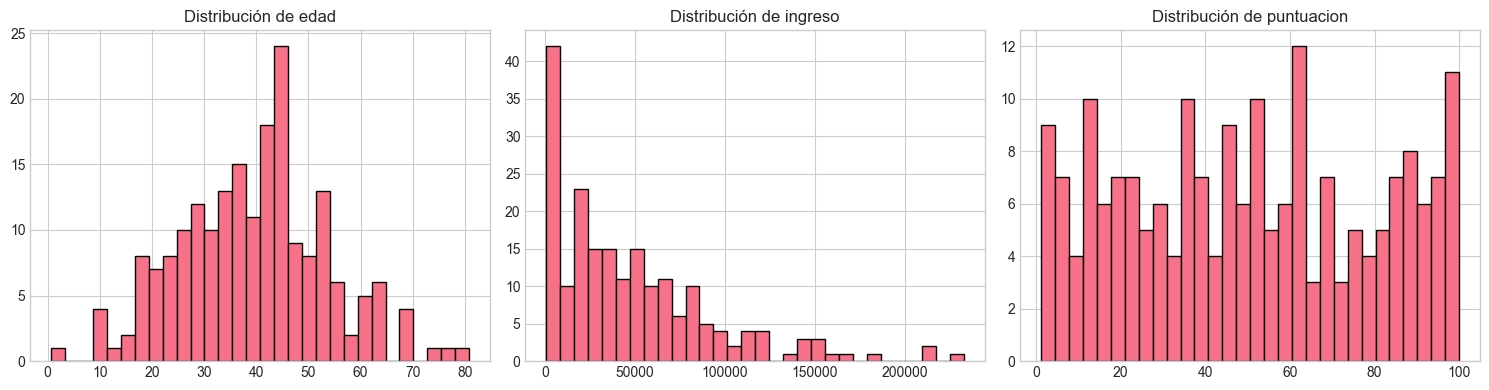

In [25]:
# Creamos datos para discretización
np.random.seed(42)
datos_discretizacion = {
    'edad': np.random.normal(40, 15, 200),
    'ingreso': np.random.exponential(50, 200) * 1000,
    'puntuacion': np.random.uniform(0, 100, 200)
}

df_disc = pd.DataFrame(datos_discretizacion)

print("📊 Datos para discretización:")
print(df_disc.describe())

# Visualización de distribuciones
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, col in enumerate(df_disc.columns):
    axes[i].hist(df_disc[col], bins=30, edgecolor='black')
    axes[i].set_title(f'Distribución de {col}')
plt.tight_layout()
plt.show()

In [26]:
# 7.1 Discretización de igual ancho (uniforme)

def discretizar_igual_ancho(df, columna, n_bins=5, labels=None):
    """
    Discretización en bins de igual ancho
    """
    return pd.cut(df[columna], bins=n_bins, labels=labels, include_lowest=True)

# Aplicamos a las tres columnas
for col in df_disc.columns:
    df_disc[f'{col}_bins_ancho'] = discretizar_igual_ancho(df_disc, col, n_bins=5)

print("📊 Discretización de igual ancho (5 bins):")
for col in df_disc.columns[:3]:
    print(f"{col} - distribución de bins:")
    print(df_disc[f'{col}_bins_ancho'].value_counts().sort_index())

📊 Discretización de igual ancho (5 bins):
edad - distribución de bins:
edad_bins_ancho
(0.623, 16.724]      8
(16.724, 32.743]    55
(32.743, 48.763]    90
(48.763, 64.783]    40
(64.783, 80.803]     7
Name: count, dtype: int64
ingreso - distribución de bins:
ingreso_bins_ancho
(312.53400000000005, 47005.921]    116
(47005.921, 93467.002]              57
(93467.002, 139928.083]             15
(139928.083, 186389.164]             9
(186389.164, 232850.245]             3
Name: count, dtype: int64
puntuacion - distribución de bins:
puntuacion_bins_ancho
(1.116, 20.967]     43
(20.967, 40.718]    39
(40.718, 60.469]    40
(60.469, 80.221]    34
(80.221, 99.972]    44
Name: count, dtype: int64


In [27]:
# 7.2 Discretización de igual frecuencia (cuantiles)

def discretizar_igual_frecuencia(df, columna, n_bins=5, labels=None):
    """
    Discretización en bins de igual frecuencia (cuantiles)
    """
    return pd.qcut(df[columna], q=n_bins, labels=labels, duplicates='drop')

# Aplicamos a las tres columnas
for col in df_disc.columns[:3]:
    df_disc[f'{col}_bins_frec'] = discretizar_igual_frecuencia(df_disc, col, n_bins=5)

print("📊 Discretización de igual frecuencia (5 bins):")
for col in df_disc.columns[:3]:
    print(f"{col} - distribución de bins:")
    print(df_disc[f'{col}_bins_frec'].value_counts().sort_index())

📊 Discretización de igual frecuencia (5 bins):
edad - distribución de bins:
edad_bins_frec
(0.703, 27.267]     40
(27.267, 36.204]    40
(36.204, 43.441]    40
(43.441, 51.117]    40
(51.117, 80.803]    40
Name: count, dtype: int64
ingreso - distribución de bins:
ingreso_bins_frec
(544.839, 6700.472]        40
(6700.472, 26479.574]      40
(26479.574, 48919.088]     40
(48919.088, 79312.354]     40
(79312.354, 232850.245]    40
Name: count, dtype: int64
puntuacion - distribución de bins:
puntuacion_bins_frec
(1.2140000000000002, 19.146]    40
(19.146, 39.482]                40
(39.482, 59.139]                40
(59.139, 81.554]                40
(81.554, 99.972]                40
Name: count, dtype: int64


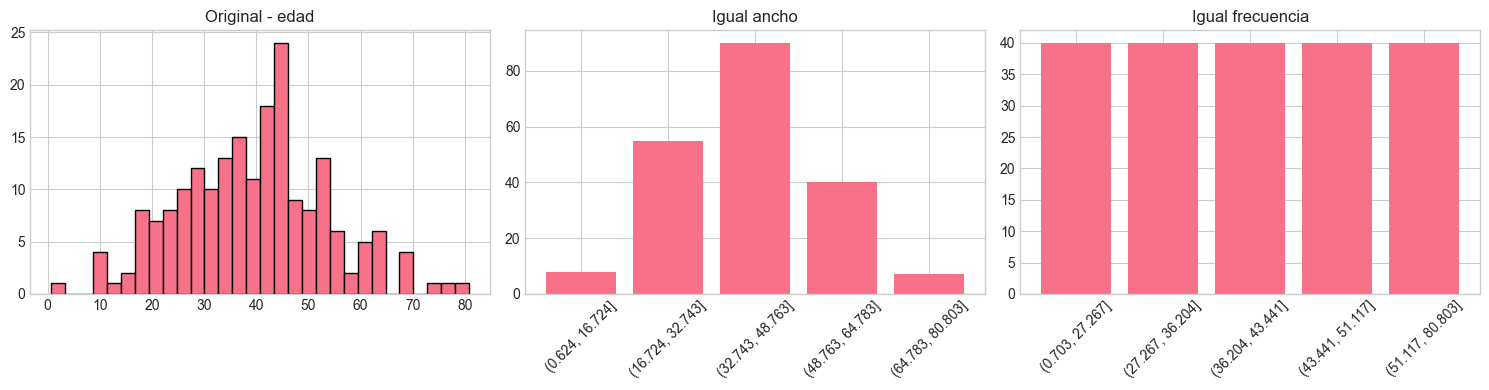

In [28]:
# 7.3 Comparación visual de métodos de discretización

col_ejemplo = 'edad'

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Original
axes[0].hist(df_disc[col_ejemplo], bins=30, edgecolor='black')
axes[0].set_title(f'Original - {col_ejemplo}')

# Igual ancho
bins_ancho = pd.cut(df_disc[col_ejemplo], bins=5).value_counts().sort_index()
axes[1].bar(range(len(bins_ancho)), bins_ancho.values, tick_label=[str(b) for b in bins_ancho.index])
axes[1].set_title('Igual ancho')
axes[1].tick_params(axis='x', rotation=45)

# Igual frecuencia
bins_frec = pd.qcut(df_disc[col_ejemplo], q=5, duplicates='drop').value_counts().sort_index()
axes[2].bar(range(len(bins_frec)), bins_frec.values, tick_label=[str(b) for b in bins_frec.index])
axes[2].set_title('Igual frecuencia')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

h:\Anaconda\envs\deepf\lib\site-packages\sklearn\preprocessing\_discretization.py:296: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(


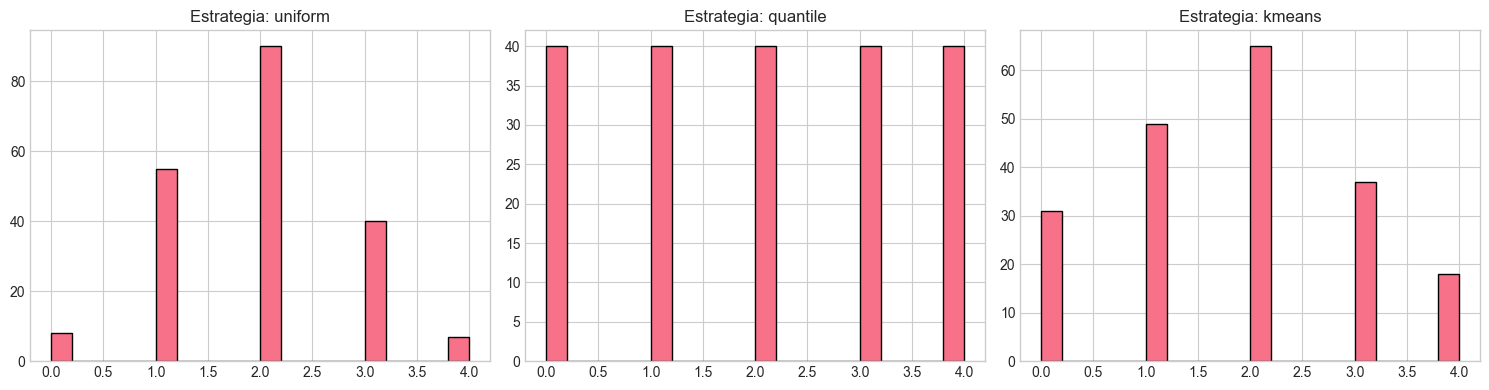

In [29]:
# 7.4 Discretización con Scikit-learn
from sklearn.preprocessing import KBinsDiscretizer

# KBinsDiscretizer con diferentes estrategias
estrategias = ['uniform', 'quantile', 'kmeans']

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i, estrategia in enumerate(estrategias):
    discretizer = KBinsDiscretizer(n_bins=5, encode='ordinal', strategy=estrategia)
    datos_discretos = discretizer.fit_transform(df_disc[['edad']])
    
    axes[i].hist(datos_discretos, bins=20, edgecolor='black')
    axes[i].set_title(f'Estrategia: {estrategia}')

plt.tight_layout()
plt.show()

## 8. Pipeline de Preprocesamiento Completo

Integramos todos los pasos en un pipeline usando datos de ejemplo (Mediciones.csv)

In [30]:
# Cargamos datos reales (Mediciones.csv)
try:
    df_mediciones = pd.read_csv('Mediciones.csv')
    print("✅ Datos cargados correctamente")
    print(f"Dimensiones: {df_mediciones.shape}")
    print(df_mediciones.head())
except:
    print("⚠️ No se encontró el archivo Mediciones.csv, creando datos similares...")
    # Creamos datos similares a Mediciones.csv
    np.random.seed(42)
    n = 100
    df_mediciones = pd.DataFrame({
        'PEEP': np.random.choice([0, 5, 10, 15], n),
        'BPM': np.random.choice([12, 15, 20, 25], n),
        'Volumen': np.random.randint(200, 500, n),
        'VTI': np.random.randint(200, 600, n),
        'VTE': np.random.randint(100, 500, n),
        'VTI_F': np.random.randint(200, 600, n),
        'VTE_F': np.random.randint(200, 600, n),
        'Pasos': np.random.randint(15000, 35000, n),
        'PEEPV': np.random.choice([0, 5, 10, 15], n)
    })
    print(df_mediciones.head())

✅ Datos cargados correctamente
Dimensiones: (24, 9)
   PEEP  BPM  Volumen  VTI  VTE  VTI_F  VTE_F  Pasos  PEEPV
0     0   12      200  251  116    226    233  17264   0.00
1     0   12      250  311  178    291    297  19934   0.00
2     0   12      300  378  242    363    367  22603   0.00
3     0   12      350  458  312    440    443  25273   0.00
4     0   12      400  524  382    524    526  27942   0.00


In [ ]:
# 8.1 Definimos el pipeline completo
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import FunctionTransformer

# Identificamos tipos de columnas
columnas_numericas = ['Volumen', 'VTI', 'VTE', 'VTI_F', 'VTE_F','PEEP', 'BPM', 'PEEPV']

# Función para eliminar outliers usando IQR
def eliminar_outliers_iqr(X, threshold=1.5):
    if isinstance(X, pd.DataFrame):
        X_clean = X.copy()
        for col in X_clean.columns:
            Q1 = X_clean[col].quantile(0.25)
            Q3 = X_clean[col].quantile(0.75)
            IQR = Q3 - Q1
            lower_bound = Q1 - threshold * IQR
            upper_bound = Q3 + threshold * IQR
            X_clean.loc[X_clean[col] < lower_bound, col] = np.nan
            X_clean.loc[X_clean[col] > upper_bound, col] = np.nan
        return X_clean
    return X

outlier_remover = FunctionTransformer(eliminar_outliers_iqr, validate=False)

# Pipeline para numéricas
numeric_pipeline = Pipeline([
    ('outlier_remover', outlier_remover),
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])



In [47]:
# 8.2 Aplicamos el pipeline

# Separamos características y target
X = df_mediciones.drop('Pasos', axis=1)
y = df_mediciones['Pasos']

print("📊 Antes del preprocesamiento:")
print(f"X shape: {X.shape}")
print(f"Columnas: {X.columns.tolist()}")

# Aplicamos preprocesamiento
X_preprocessed = numeric_pipeline.fit_transform(X)

print("📊 Después del preprocesamiento:")
print(f"X_preprocessed shape: {X_preprocessed.shape}")

📊 Antes del preprocesamiento:
X shape: (24, 8)
Columnas: ['PEEP', 'BPM', 'Volumen', 'VTI', 'VTE', 'VTI_F', 'VTE_F', 'PEEPV']
📊 Después del preprocesamiento:
X_preprocessed shape: (24, 8)


📊 Resultados del modelo con pipeline completo:
MSE: 0.12
R²: 1.0000


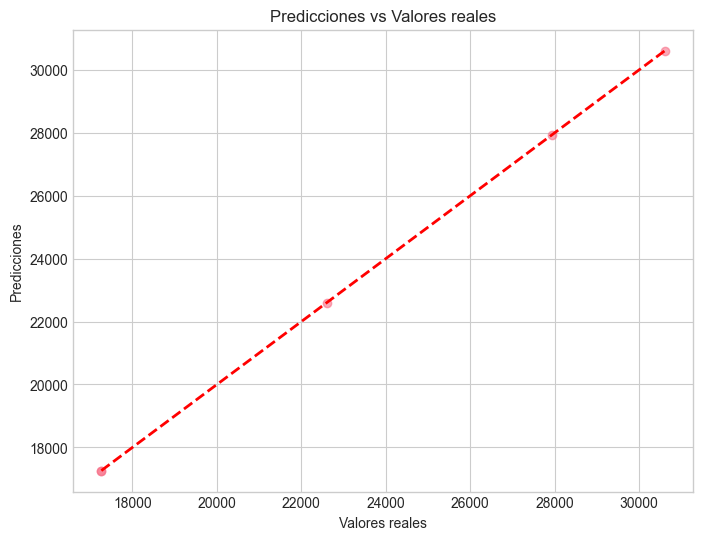

In [48]:
# 8.3 Modelo completo con pipeline
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# Pipeline completo (preprocesamiento + modelo)
full_pipeline = Pipeline([
    ('preprocessor', numeric_pipeline),
    ('regressor', LinearRegression())
])

# Dividimos datos
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Entrenamos
full_pipeline.fit(X_train, y_train)

# Predecimos
y_pred = full_pipeline.predict(X_test)

# Evaluamos
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("📊 Resultados del modelo con pipeline completo:")
print(f"MSE: {mse:.2f}")
print(f"R²: {r2:.4f}")

# Gráfico de predicciones vs reales
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Valores reales')
plt.ylabel('Predicciones')
plt.title('Predicciones vs Valores reales')
plt.show()

📊 Comparación de pipelines:
               Pipeline       MSE   R²
0  Sin preprocesamiento 205129.49 0.99
1          Con escalado 198720.52 0.99
2     Pipeline completo      0.12 1.00


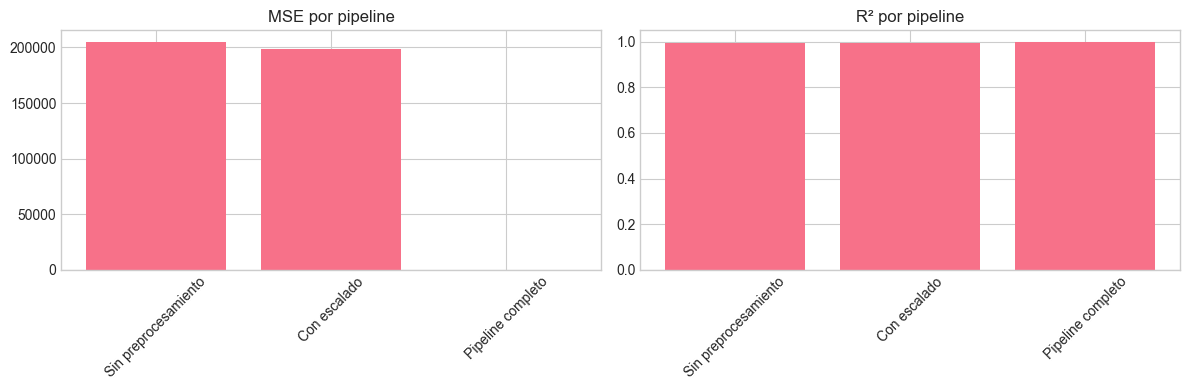

In [34]:
# 8.4 Comparación con diferentes estrategias de preprocesamiento

from sklearn.ensemble import RandomForestRegressor

# Diferentes pipelines para comparar
pipelines = {
    'Sin preprocesamiento': Pipeline([
        ('regressor', RandomForestRegressor(random_state=42))
    ]),
    'Con escalado': Pipeline([
        ('scaler', StandardScaler()),
        ('regressor', RandomForestRegressor(random_state=42))
    ]),
    'Pipeline completo': full_pipeline
}

resultados = []

for nombre, pipeline in pipelines.items():
    try:
        pipeline.fit(X_train, y_train)
        y_pred = pipeline.predict(X_test)
        mse = mean_squared_error(y_test, y_pred)
        r2 = r2_score(y_test, y_pred)
        resultados.append({'Pipeline': nombre, 'MSE': mse, 'R²': r2})
    except Exception as e:
        print(f"Error en {nombre}: {e}")

df_resultados = pd.DataFrame(resultados)
print("📊 Comparación de pipelines:")
print(df_resultados)

# Visualización
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(df_resultados['Pipeline'], df_resultados['MSE'])
axes[0].set_title('MSE por pipeline')
axes[0].tick_params(axis='x', rotation=45)

axes[1].bar(df_resultados['Pipeline'], df_resultados['R²'])
axes[1].set_title('R² por pipeline')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## 9. Resumen y Buenas Prácticas

### Checklist de Preprocesamiento:

1. **Análisis inicial**
   - [ ] Explorar tipos de datos
   - [ ] Identificar valores nulos
   - [ ] Detectar outliers
   - [ ] Analizar distribuciones

2. **Limpieza**
   - [ ] Manejar valores nulos (eliminación/imputación)
   - [ ] Tratar outliers (eliminación, winsorizing, transformación)
   - [ ] Corregir inconsistencias

3. **Transformación**
   - [ ] Escalar/normalizar variables numéricas
   - [ ] Codificar variables categóricas
   - [ ] Discretizar si es necesario
   - [ ] Crear nuevas características (feature engineering)

4. **Validación**
   - [ ] Verificar que no hay fugas de datos (data leakage)
   - [ ] Aplicar mismo preprocesamiento a train/test
   - [ ] Usar pipelines para reproducibilidad

### Recomendaciones:

* ✅ Siempre separar train/test **antes** de preprocesar
* ✅ Ajustar (fit) escaladores/imputadores solo en train
* ✅ Usar pipelines para evitar fugas de datos
* ✅ Documentar todas las transformaciones aplicadas
* ✅ Validar impacto de cada paso en el modelo final